# Data Preparation on Open-Meteo Dataset

In [1]:
import pandas as pd

from src.compare import compare_transformations, compare_skewness, compare_distributions
from src.derive import derive_epi
from src.enums import aq_keys, prefixes, prep_keys, files
from src.transform import Transformation, transform

aq = pd.read_csv(files['data/03-26-open-meteo-pre-narrowed.csv'])

## Clean up air quality data

Remove mostly null and non-representative columns from air quality data.

In [2]:
aq_cleaned = aq.copy()
aq_cleaned = aq_cleaned.drop([
    aq_keys['methane (μg/m³)'], # Dropped because half the data is missing.
    aq_keys['carbon_dioxide (ppm)'], # Dropped because half the data is missing.
], axis=1)

aq_columns_with_null = []

for key in aq_cleaned.columns.tolist():
    null_count = aq_cleaned[key].isna().sum()
    if null_count > 0:
        aq_columns_with_null.append(key)

print(f"Columns with null values: {len(aq_columns_with_null)}")
aq_cleaned.head(3)

Columns with null values: 0


,time,us_aqi (USAQI),us_aqi_pm2_5 (USAQI),us_aqi_pm10 (USAQI),us_aqi_nitrogen_dioxide (USAQI),us_aqi_carbon_monoxide (USAQI),us_aqi_ozone (USAQI),us_aqi_sulphur_dioxide (USAQI),uv_index_clear_sky (),uv_index (),dust (μg/m³),aerosol_optical_depth (),ozone (μg/m³),sulphur_dioxide (μg/m³),nitrogen_dioxide (μg/m³),pm2_5 (μg/m³),carbon_monoxide (μg/m³),pm10 (μg/m³)
0,2023-07-01 0:00,45,45,15,14,2,31,2,0.0,0.0,0,0.1,21,3.9,28.8,14.5,246,21.8
1,2023-07-01 1:00,45,45,15,15,2,26,2,0.0,0.0,0,0.1,16,3.6,30.8,14.5,264,21.7
2,2023-07-01 2:00,46,46,15,15,2,21,2,0.0,0.0,0,0.1,14,3.3,31.1,14.2,270,21.1


## Stabilize air quality data

Apply transformation to skewed columns to stabilize variance and make the data more normally distributed.

### Compare skewness across different transformations

In [3]:
compare_transformations(aq_cleaned)

,Original,Square root,Log transformation,Cube root,Yeo-Johnson Transform
time,N/A,N/A,N/A,N/A,N/A
us_aqi (USAQI),0.81,0.33,-0.09,0.18,-0.0
us_aqi_pm2_5 (USAQI),0.39,-0.07,-0.55,-0.23,-0.04
us_aqi_pm10 (USAQI),0.67,0.07,-0.42,-0.13,-0.0
us_aqi_nitrogen_dioxide (USAQI),1.27,0.61,0.13,0.3,0.02
us_aqi_carbon_monoxide (USAQI),1.75,0.84,0.5,0.57,-0.0
us_aqi_ozone (USAQI),0.58,-0.45,-1.32,-0.8,-0.01
us_aqi_sulphur_dioxide (USAQI),1.5,-0.59,-0.16,-1.55,0.01
uv_index_clear_sky (),1.88,1.03,1.08,0.67,0.58
uv_index (),2.04,1.14,1.21,0.75,0.63


### Transform skewed features

In [4]:
transformations = {
    aq_keys['us_aqi (USAQI)']: Transformation.SQRT,
    aq_keys['us_aqi_pm10 (USAQI)']: Transformation.SQRT,
    aq_keys['pm10 (μg/m³)']: Transformation.SQRT,

    aq_keys['us_aqi_nitrogen_dioxide (USAQI)']: Transformation.LOG1P,
    aq_keys['us_aqi_carbon_monoxide (USAQI)']: Transformation.LOG1P,
    aq_keys['us_aqi_sulphur_dioxide (USAQI)']: Transformation.LOG1P,
    aq_keys['sulphur_dioxide (μg/m³)']: Transformation.LOG1P,
    aq_keys['nitrogen_dioxide (μg/m³)']: Transformation.LOG1P,
    aq_keys['pm2_5 (μg/m³)']: Transformation.LOG1P,

    aq_keys['us_aqi_ozone (USAQI)']: Transformation.YEO_JOHNSON,
    aq_keys['carbon_monoxide (μg/m³)']: Transformation.YEO_JOHNSON,
}
aq_transformed = transform(
    aq_cleaned,
    transformations,
    prefixes['03_30_data_preparation_yeo_johnson_']
)

### Skewness comparison

In [5]:
compare_skewness(aq_cleaned, aq_transformed, transformations)

,Changes,Skewness (Original),Skewness (Target)
us_aqi (USAQI),sqrt,0.81,0.33
us_aqi_pm10 (USAQI),sqrt,0.67,0.07
pm10 (μg/m³),sqrt,1.04,0.24
us_aqi_nitrogen_dioxide (USAQI),log1p,1.27,0.13
us_aqi_carbon_monoxide (USAQI),log1p,1.75,0.5
us_aqi_sulphur_dioxide (USAQI),log1p,1.5,-0.16
sulphur_dioxide (μg/m³),log1p,1.8,0.26
nitrogen_dioxide (μg/m³),log1p,1.28,0.04
pm2_5 (μg/m³),log1p,1.59,-0.08
us_aqi_ozone (USAQI),yeo-johnson,0.58,-0.01


### Distribution comparison

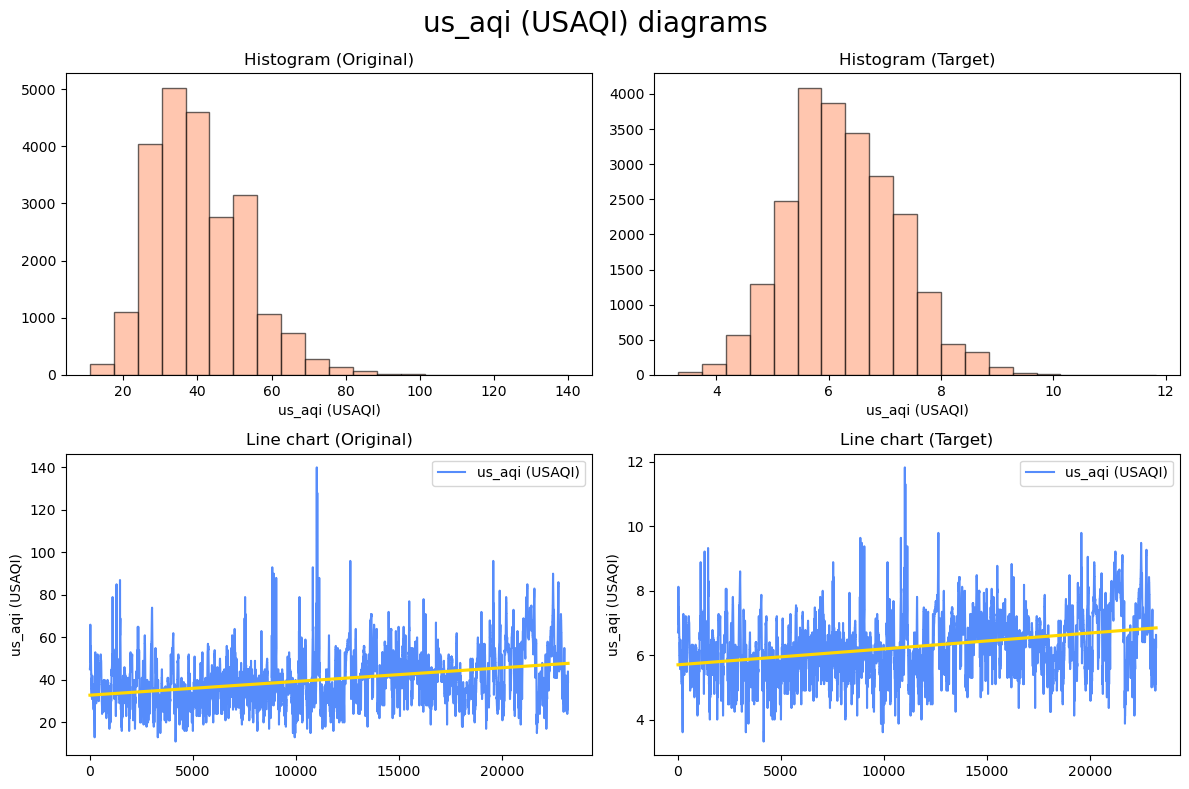

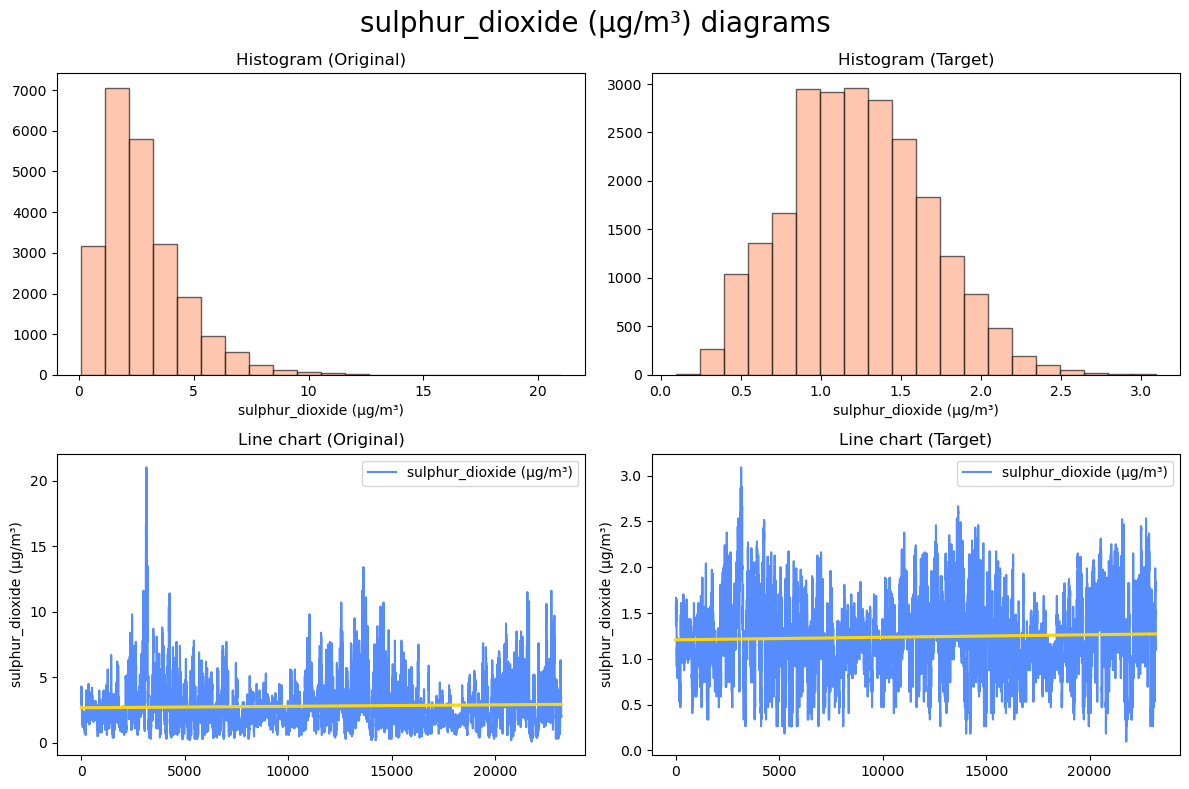

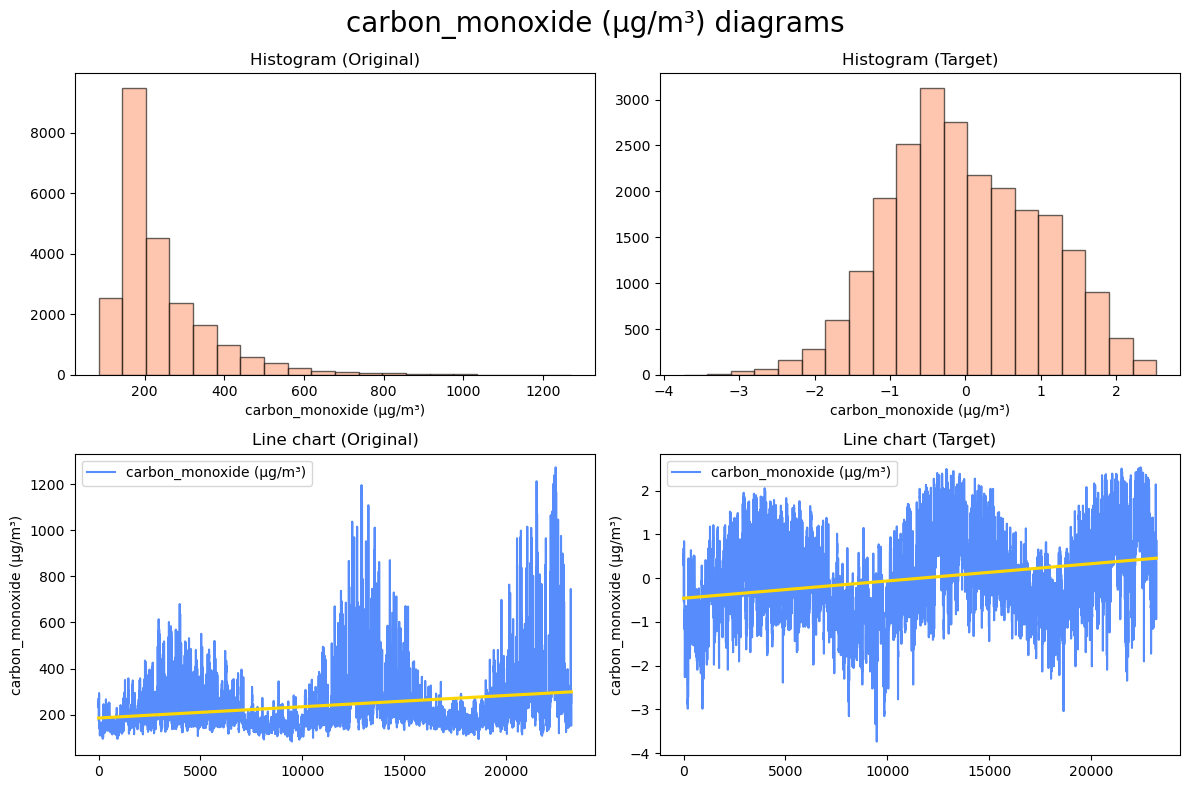

In [6]:
compare_distributions(
    aq_cleaned,
    aq_transformed,
    [
        aq_keys['us_aqi (USAQI)'], # square root transformation.
        aq_keys['sulphur_dioxide (μg/m³)'], # log transformation.
        aq_keys['carbon_monoxide (μg/m³)'] # Yeo-Johnson transformation.
    ]
)

## Revert transformation

After aggregation, the previously stabilized data become skewed again. We are applying transformation after aggregation to reduce steps. Also, transformations that result in negative values have limited transformation options later, as they cannot be square-rooted.

## Aggregate air quality data

Aggregate air quality by week to match the granularity of respiratory virus data.

In [7]:
aq_aggregated = aq_cleaned.copy()

aq_aggregated[[
    prep_keys['SEASON'],
    prep_keys['WEEKENDING'],
    prep_keys['MMWR_WEEK'],
    prep_keys['MMWR_YEAR']
]] = aq_aggregated[aq_keys['time']].apply(lambda x: pd.Series(derive_epi(x)))
aq_aggregated = aq_aggregated.drop([aq_keys['time']], axis=1)
aq_aggregated = aq_aggregated.groupby([
    prep_keys['SEASON'],
    prep_keys['WEEKENDING'],
    prep_keys['MMWR_WEEK'],
    prep_keys['MMWR_YEAR']
]).agg({
    prep_keys['us_aqi (USAQI)']: 'max',
    prep_keys['us_aqi_pm2_5 (USAQI)']: 'max',
    prep_keys['us_aqi_pm10 (USAQI)']: 'max',
    prep_keys['us_aqi_nitrogen_dioxide (USAQI)']: 'max',
    prep_keys['us_aqi_carbon_monoxide (USAQI)']: 'max',
    prep_keys['us_aqi_ozone (USAQI)']: 'max',
    prep_keys['us_aqi_sulphur_dioxide (USAQI)']: 'max',
    prep_keys['uv_index ()']: 'max',
    prep_keys['uv_index_clear_sky ()']: 'max',
    prep_keys['dust (μg/m³)']: 'mean',
    prep_keys['aerosol_optical_depth ()']: 'mean',
    prep_keys['ozone (μg/m³)']: 'mean',
    prep_keys['sulphur_dioxide (μg/m³)']: 'mean',
    prep_keys['nitrogen_dioxide (μg/m³)']: 'mean',
    prep_keys['pm2_5 (μg/m³)']: 'mean',
    prep_keys['carbon_monoxide (μg/m³)']: 'mean',
    prep_keys['pm10 (μg/m³)']: 'mean',
}).reset_index()

aq_aggregated.head(3)

,SEASON,WEEKENDING,MMWR_WEEK,MMWR_YEAR,us_aqi (USAQI),us_aqi_pm2_5 (USAQI),us_aqi_pm10 (USAQI),us_aqi_nitrogen_dioxide (USAQI),us_aqi_carbon_monoxide (USAQI),us_aqi_ozone (USAQI),...,uv_index (),uv_index_clear_sky (),dust (μg/m³),aerosol_optical_depth (),ozone (μg/m³),sulphur_dioxide (μg/m³),nitrogen_dioxide (μg/m³),pm2_5 (μg/m³),carbon_monoxide (μg/m³),pm10 (μg/m³)
0,2022/2023,07/01/2023,26,2023,66,49,16,15,2,66,...,10.20,10.20,0.416667,0.096250,68.458333,3.475000,15.450000,11.891667,224.791667,18.079167
1,2023/2024,01/06/2024,1,2024,41,41,13,27,5,35,...,2.10,2.20,0.053571,0.067381,41.184524,3.052976,21.955952,6.779167,255.738095,10.582738
2,2023/2024,01/13/2024,2,2024,38,38,14,29,3,35,...,2.05,2.85,0.172619,0.057083,43.684524,3.073214,22.157143,5.580952,230.946429,9.106548


## Checkpoint

In [8]:
aq_checkpoint = aq_aggregated.copy()
aq_checkpoint = aq_checkpoint.sort_values(by=[prep_keys['MMWR_YEAR'], prep_keys['MMWR_WEEK']])
aq_checkpoint.to_csv(files['data/04-01-open-meteo-cleaned-aggregated.csv'], index=False)